数据集基本信息
数据集形状: (8494, 22385)
细胞/spot数量: 8494
基因数量: 22385

主要数据结构
AnnData对象类型: <class 'anndata._core.anndata.AnnData'>
主要数据矩阵 (X): (8494, 22385)
数据类型: <class 'scipy.sparse._csr.csr_matrix'>

观察值维度 (obs) - 细胞/spot的元数据
obs列数: 566
obs列名: ['SCT_snn_res.0.8', 'annotation', 'lineage', 'nCount_RNA', 'nCount_SCT', 'nFeature_RNA', 'nFeature_SCT', 'orig.ident', 'percent.mt', 'primaryanno', 'refindedanno', 'seurat_clusters', 'simpleanno', 'annotation3', 'Regulon - 5730507C01Rik', 'Regulon - AU041133', 'Regulon - Acaa1b', 'Regulon - Adnp', 'Regulon - Alx1', 'Regulon - Alx3', 'Regulon - Alx4', 'Regulon - Arnt2', 'Regulon - Ascl1', 'Regulon - Atf1', 'Regulon - Atf2', 'Regulon - Atf3', 'Regulon - Atf6b', 'Regulon - Atf7', 'Regulon - Atoh1', 'Regulon - Atoh7', 'Regulon - B230307C23Rik', 'Regulon - Bach2', 'Regulon - Barhl1', 'Regulon - Barhl2', 'Regulon - Barx1', 'Regulon - Batf', 'Regulon - Bbx', 'Regulon - Bcl3', 'Regulon - Bcl6', 'Regulon - Bcl6b', 'Regulon - Bclaf1', 'Regulon - Bhlha15', 'Regulon -

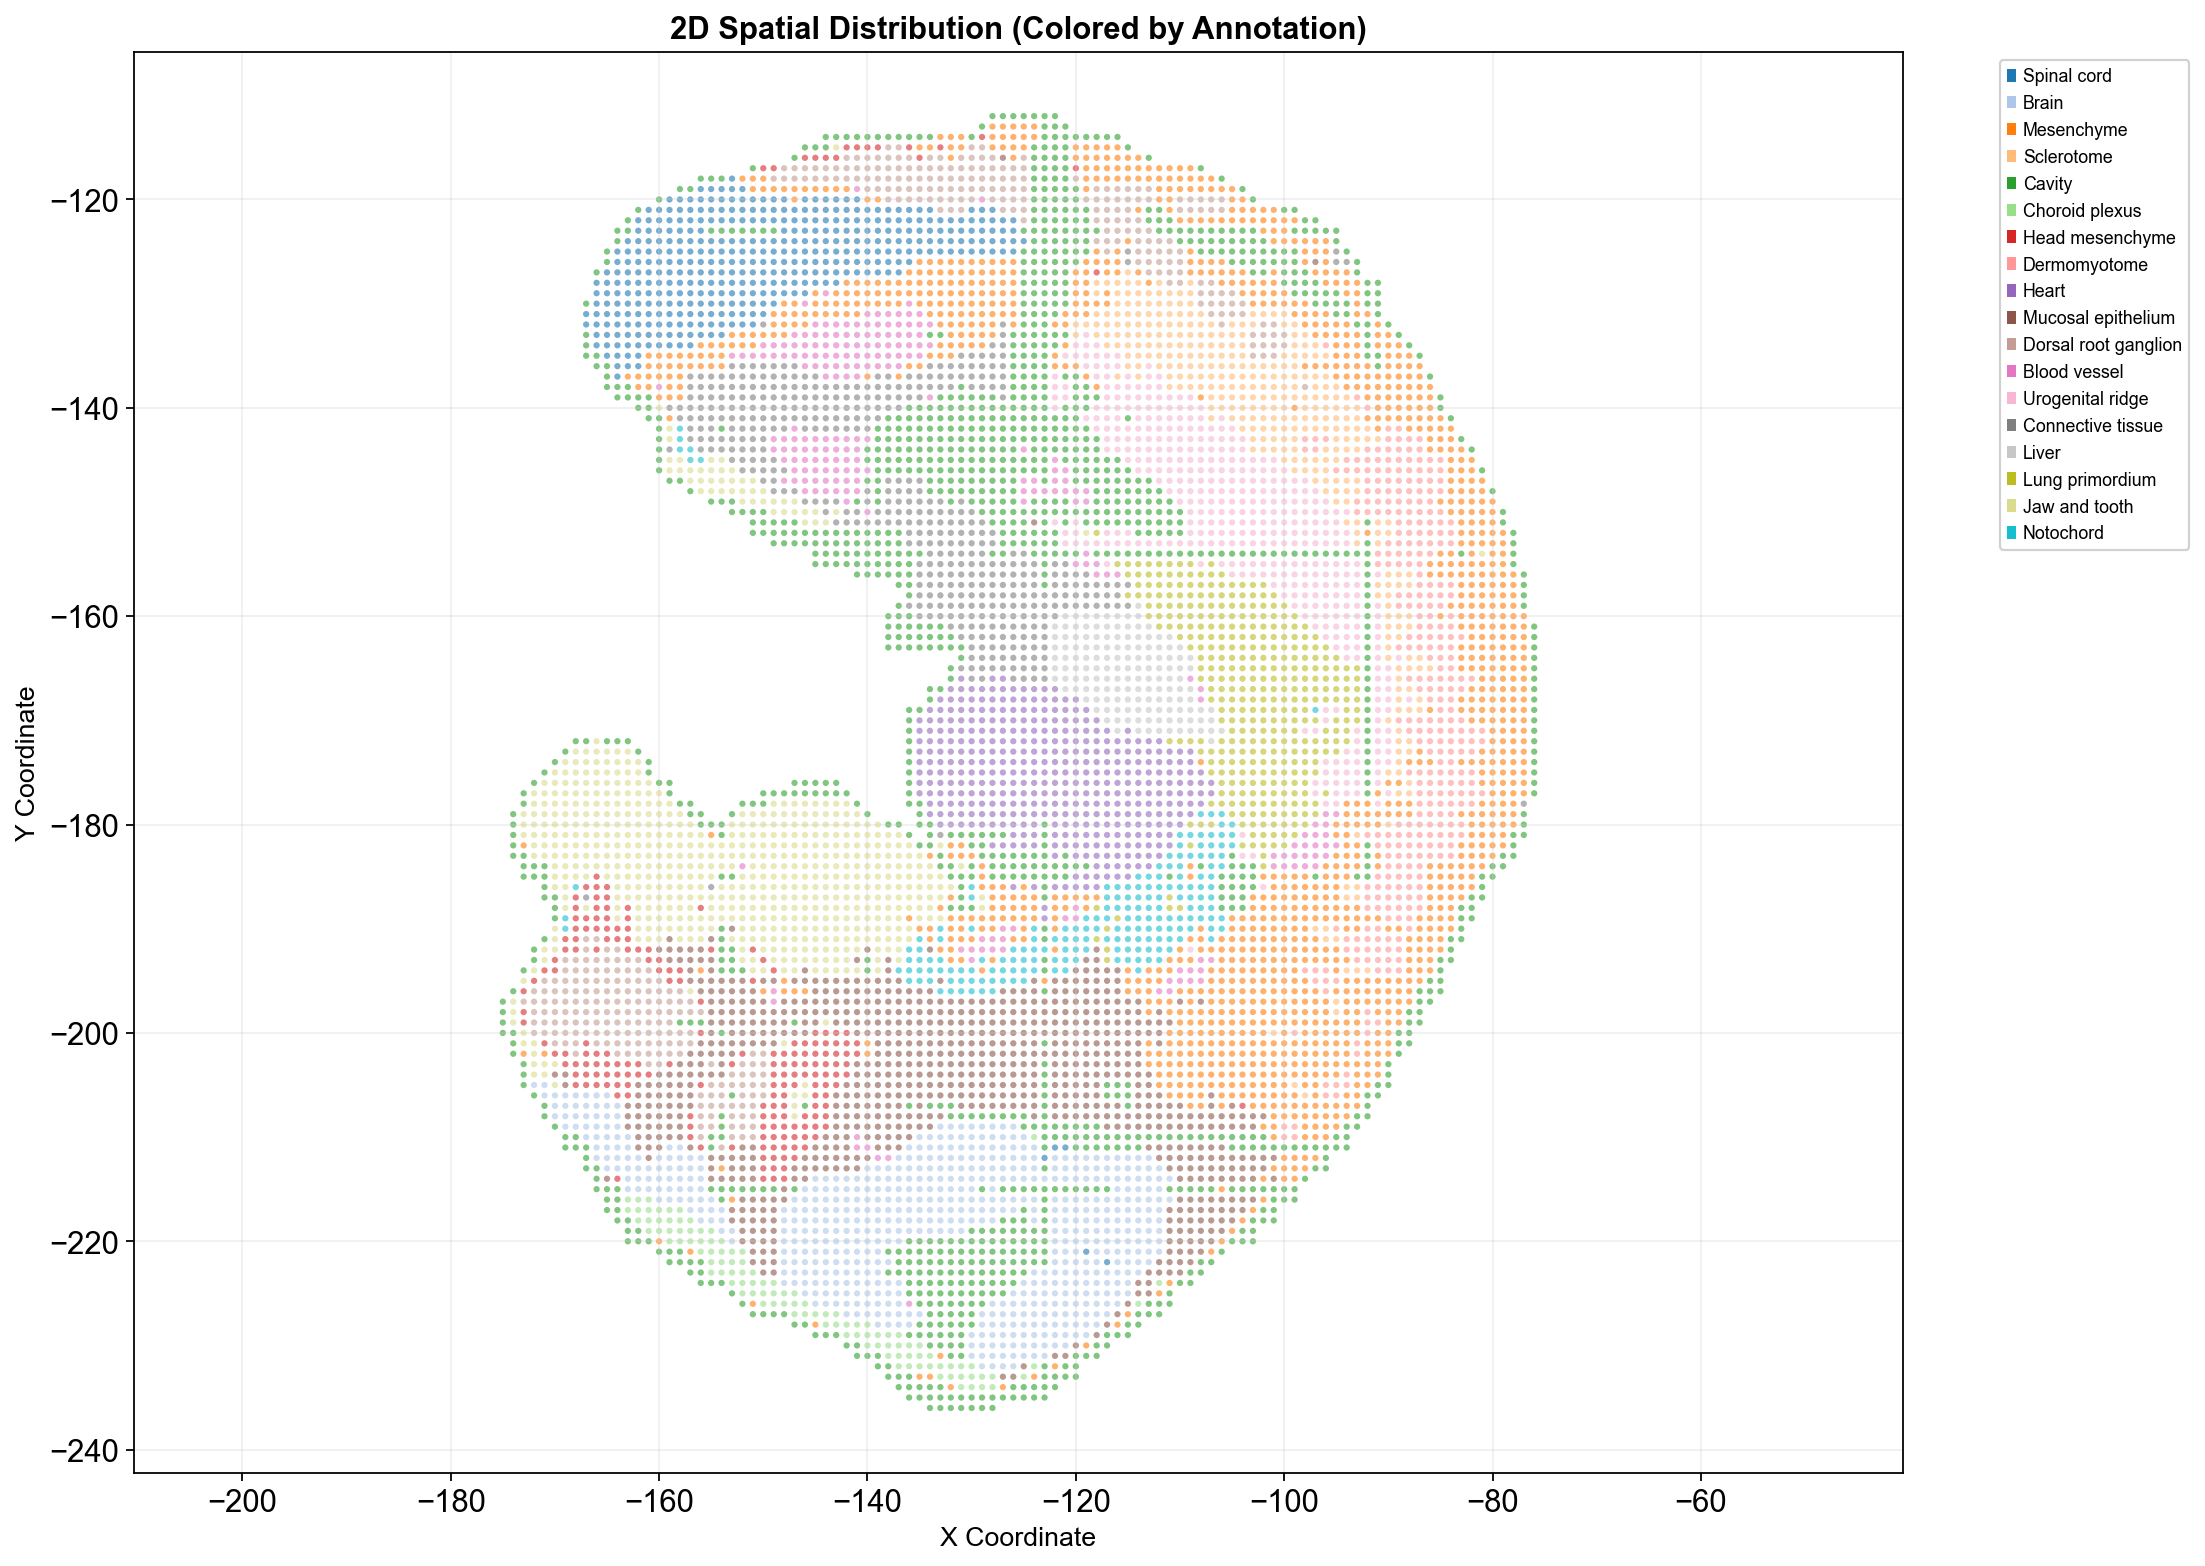


Annotation类别数量: 18
Annotation类别: ['Spinal cord', 'Brain', 'Mesenchyme', 'Sclerotome', 'Cavity', 'Choroid plexus', 'Head mesenchyme', 'Dermomyotome', 'Heart', 'Mucosal epithelium', 'Dorsal root ganglion', 'Blood vessel', 'Urogenital ridge', 'Connective tissue', 'Liver', 'Lung primordium', 'Jaw and tooth', 'Notochord']

空间坐标统计信息:
坐标数量: 8494
坐标维度: 2
X坐标范围: [-175.00, -76.00]
Y坐标范围: [-236.00, -112.00]
X坐标均值: -124.29, 标准差: 23.83
Y坐标均值: -172.71, 标准差: 32.16


In [ ]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 设置scanpy参数
sc.settings.verbosity = 3  # 显示详细信息
sc.settings.set_figure_params(dpi=80, facecolor='white')

# 加载表达量数据 (h5ad文件)
expr_data_path = '../data/E10.5_E2S1.MOSTA.h5ad'
adata = sc.read_h5ad(expr_data_path)

print("=" * 60)
print("Dataset Summary")
print("=" * 60)
print(f"Shape: {adata.shape[0]} cells/spots × {adata.shape[1]} genes")
print(f"Data matrix type: {'Sparse' if hasattr(adata.X, 'toarray') else 'Dense'}")
print(f"obs columns: {adata.obs.shape[1]}")
print(f"var columns: {adata.var.shape[1]}")

# 空间坐标信息
if 'spatial' in adata.obsm.keys():
    spatial_shape = adata.obsm['spatial'].shape
    print(f"Spatial coordinates: {spatial_shape[0]} points × {spatial_shape[1]} dimensions")
else:
    print("Spatial coordinates: Not found")

# 绘制2D空间位置分布图
if 'spatial' in adata.obsm.keys():
    spatial_coords = adata.obsm['spatial']
    # 转换为numpy数组（如果是DataFrame或其他类型）
    if hasattr(spatial_coords, 'values'):
        spatial_coords = spatial_coords.values
    elif hasattr(spatial_coords, 'to_numpy'):
        spatial_coords = spatial_coords.to_numpy()
    else:
        spatial_coords = np.array(spatial_coords)
    
    print("\n" + "=" * 60)
    print("Spatial Visualization")
    print("=" * 60)
    
    # 按照annotation着色
    if 'annotation' in adata.obs.columns:
        annotations = adata.obs['annotation'].values
        unique_annotations = pd.Series(annotations).unique()
        n_annotations = len(unique_annotations)
        
        # 使用tab20颜色映射，如果类别太多则使用其他colormap
        if n_annotations <= 20:
            cmap = plt.cm.tab20
        elif n_annotations <= 40:
            cmap = plt.cm.tab40
        else:
            cmap = plt.cm.Set3
        
        # 为每个annotation创建颜色映射
        annotation_to_color = {ann: cmap(i / max(n_annotations, 1)) for i, ann in enumerate(unique_annotations)}
        colors = [annotation_to_color[ann] for ann in annotations]
        
        # 绘制空间分布图
        fig, ax = plt.subplots(figsize=(14, 10))
        scatter = ax.scatter(spatial_coords[:, 0], spatial_coords[:, 1], 
                            s=8, alpha=0.6, c=colors, edgecolors='none')
        ax.set_xlabel('X Coordinate', fontsize=12)
        ax.set_ylabel('Y Coordinate', fontsize=12)
        ax.set_title('2D Spatial Distribution (Colored by Annotation)', fontsize=14, fontweight='bold')
        ax.grid(True, alpha=0.3)
        ax.axis('equal')
        
        # 添加图例
        from matplotlib.patches import Patch
        legend_elements = [Patch(facecolor=annotation_to_color[ann], label=ann) 
                          for ann in unique_annotations]
        ax.legend(handles=legend_elements, bbox_to_anchor=(1.05, 1), loc='upper left', 
                 fontsize=8, ncol=1, framealpha=0.9)
        
        plt.tight_layout()
        plt.show()
        
        print(f"Annotation categories: {n_annotations}")
    else:
        # 如果没有annotation列，使用默认颜色
        plt.figure(figsize=(12, 10))
        plt.scatter(spatial_coords[:, 0], spatial_coords[:, 1], 
                   s=8, alpha=0.6, c='steelblue', edgecolors='none')
        plt.xlabel('X Coordinate', fontsize=12)
        plt.ylabel('Y Coordinate', fontsize=12)
        plt.title('2D Spatial Distribution', fontsize=14, fontweight='bold')
        plt.grid(True, alpha=0.3)
        plt.axis('equal')
        plt.tight_layout()
        plt.show()
        print("Note: 'annotation' column not found, using default color")
    
    print(f"\nSpatial coordinates range:")
    print(f"  X: [{spatial_coords[:, 0].min():.1f}, {spatial_coords[:, 0].max():.1f}]")
    print(f"  Y: [{spatial_coords[:, 1].min():.1f}, {spatial_coords[:, 1].max():.1f}]")
else:
    print("\nError: 'spatial' key not found in obsm")
